## Running example from the readme


In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
# Data preprocessing. Tedious, but PyPOTS can help.
import numpy as np
from sklearn.preprocessing import StandardScaler
from pygrinder import mcar
from pypots.data import load_specific_dataset
data = load_specific_dataset('physionet_2012')  # PyPOTS will automatically download and extract it.


2024-11-28 12:12:38 [INFO]: Loading the dataset physionet_2012 with TSDB (https://github.com/WenjieDu/Time_Series_Data_Beans)...
2024-11-28 12:12:38 [INFO]: Starting preprocessing physionet_2012...
2024-11-28 12:12:38 [INFO]: You're using dataset physionet_2012, please cite it properly in your work. You can find its reference information at the below link: 
https://github.com/WenjieDu/TSDB/tree/main/dataset_profiles/physionet_2012
2024-11-28 12:12:38 [INFO]: Dataset physionet_2012 has already been downloaded. Processing directly...
2024-11-28 12:12:38 [INFO]: Dataset physionet_2012 has already been cached. Loading from cache directly...
2024-11-28 12:12:38 [ERROR]: ❌ Loading data failed. Operation aborted. Investigate the error below:
No module named 'pandas.core.indexes.numeric'
2024-11-28 12:12:38 [INFO]: Loaded successfully!


TypeError: 'NoneType' object is not subscriptable

In [4]:
! rm ~/.pypots/tsdb/pysionet_2012

rm: /Users/louis/.pypots/tsdb/pysionet_2012: No such file or directory


In [5]:
help(load_specific_dataset)

Help on function load_specific_dataset in module pypots.data.load_specific_datasets:

load_specific_dataset(dataset_name: str, use_cache: bool = True) -> dict
    Load specific datasets supported by PyPOTS.
    Different from tsdb.load(), which only produces merely raw data,
    load_specific_dataset here does some preprocessing operations,
    like truncating time series to generate samples with the same length.
    
    Parameters
    ----------
    dataset_name :
        The name of the dataset to be loaded, which should be supported, i.e. in SUPPORTED_DATASETS.
    
    use_cache :
        Whether to use cache. This is an argument of tsdb.load().
    
    Returns
    -------
    data :
        A dict contains the preprocessed dataset.
        Users only need to continue the preprocessing steps to generate the data they want,
        e.g. standardizing and splitting.



In [4]:
import torch
torch.isnan(torch.tensor(X)).float().mean()

NameError: name 'X' is not defined

In [ ]:
from sklearn.preprocessing import QuantileTransformer


X = data['train_X'].copy()
scaler = data['scaler']
X_shape = X.shape
X = scaler.transform(X.reshape(-1,X_shape[2])).reshape(X_shape)

quantile_normalize = False
min_max_scaling = False

## normalize
normalize = True
if normalize and not quantile_normalize:
    latent_dim = X.shape[2]
    mean, std = np.zeros((1,1,latent_dim)), np.ones((1,1,latent_dim))
    for l in range(latent_dim):
        X_l = X[:,:,l][~np.isnan(X[:, :, l])] 
        if len(X_l) > 0:   
            if min_max_scaling:
                mean[:,:,l] = X_l.mean() 
                if X_l.std() > 0:
                    std[:,:,l] = X_l.max() - X_l.min()              
            else:
                mean[:,:,l] = X_l.mean() 
                if X_l.std() > 0:
                    std[:,:,l] = X_l.std()   
                #std[:,:,l] = X_l.std()   
    X = (X - mean) / std


else:

    rng = np.random.RandomState(0)
    qt = QuantileTransformer(n_quantiles=10, random_state=0, output_distribution = 'normal')

    n_batch, n_obs, latent_dim = X.shape
    for l in range(latent_dim):
        X_l = X[:,:,l][X[:,:,l]==X[:,:,l]] 
        qt.fit(X_l.reshape(-1,1))
        
        X[:,:,l] = qt.transform(X[:,:,l].reshape(-1,1)).reshape(n_batch, n_obs)


X_ori = X  # keep X_ori for validation
X = mcar(X, 0.1)  # randomly hold out 10% observed values as ground truth
X[X>3] = 3
X[X<-3] = -3
dataset = {"X": X[:10000]}  # X for model input
print(X.shape)  # (11988, 48, 37), 11988 samples and each sample has 48 time steps, 37 features

(7671, 48, 37)


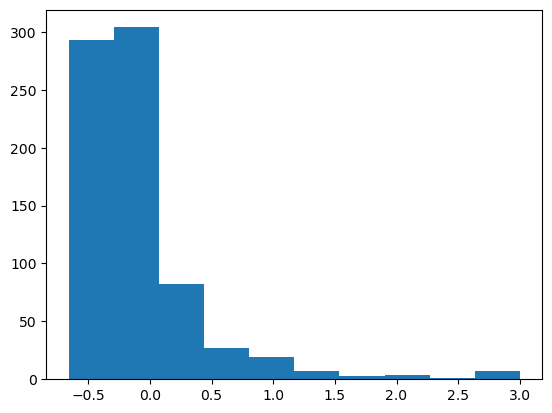

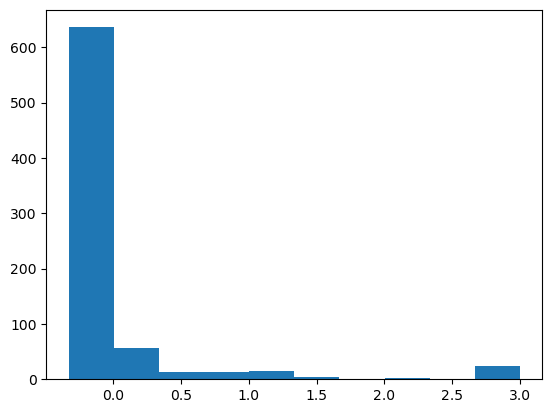

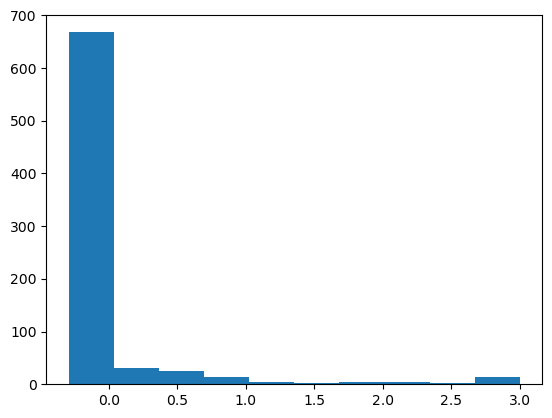

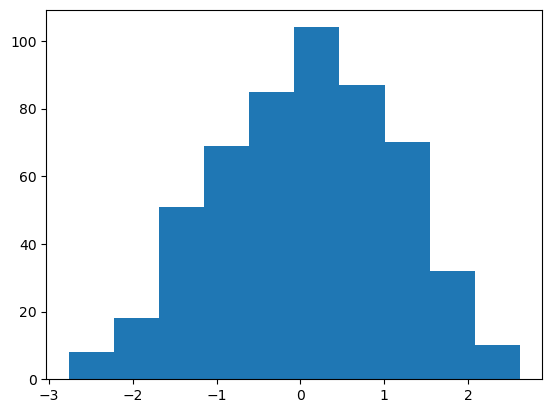

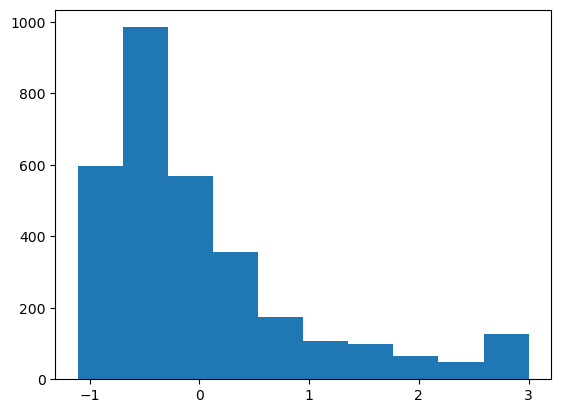

In [ ]:
import matplotlib.pyplot as plt 
num_dims = X.shape[2]
for j in range(num_dims)[:5]:
    plt.hist(X[:1000,:,j].flatten())
    plt.show()

In [ ]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GP_VAE
from pypots.utils.metrics import calc_mae
from pypots.optim.adam import Adam
from torch.optim.lr_scheduler import LRScheduler

gpvae = GP_VAE(n_steps = 48, 
            n_features = 37, 
            latent_size = 16, 
            epochs = 300, 
            batch_size = 64,
            beta = 1, 
            K = 10,  
            encoder_sizes = (128, 64), 
            decoder_sizes = (64, 128),
            optimizer = Adam(weight_decay = 1e-4) #, lr_scheduler = LRScheduler
            )

gpvae.model.backbone.p = 0.1
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
gpvae.fit(dataset)  # train the model on the dataset

2024-11-18 15:41:26 [INFO]: No given device, using default device: cpu
2024-11-18 15:41:26 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2024-11-18 15:41:26 [INFO]: GP_VAE initialized with the given hyperparameters, the number of trainable parameters: 32,933


Model dimensions is: 
GpvaeEncoder(
  (net): Sequential(
    (0): Linear(in_features=74, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU()
  )
  (mu_layer): Linear(in_features=64, out_features=16, bias=True)
  (logvar_layer): Linear(in_features=64, out_features=16, bias=True)
)
GpvaeDecoder(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=37, bias=True)
  )
)


: 

: 

In [ ]:
gpvae.model.backbone.p = .2
gpvae.model.backbone.sampling = True
gpvae.fit(dataset)  # train the model on the dataset

2024-11-18 15:40:17 [ERROR]: ❌ Exception: None


elbo too big 964.1619262695312 385.5335388183594 0.13932065665721893


RuntimeError: Training got interrupted. Model was not trained. Please investigate the error printed above.

In [ ]:
import gpytorch
import torch
with gpytorch.settings.cholesky_jitter(1e-4):
    with torch.autograd.set_detect_anomaly(True):
        gpvae.fit_kernel(dataset)  # train the model on the dataset


fitting kernel


KeyboardInterrupt: 

In [ ]:
gpvae.gp.gp_models[0].covar_module.outputscale


tensor([0.6444, 0.6444, 0.6444, 0.6444, 0.6444, 0.6444, 0.6444, 0.6444],
       grad_fn=<SoftplusBackward0>)

In [ ]:
help(gpvae.gp.gp_models[0].covar_module)


Help on ScaleKernel in module gpytorch.kernels.scale_kernel object:

class ScaleKernel(gpytorch.kernels.kernel.Kernel)
 |  ScaleKernel(base_kernel: gpytorch.kernels.kernel.Kernel, outputscale_prior: Optional[gpytorch.priors.prior.Prior] = None, outputscale_constraint: Optional[gpytorch.constraints.constraints.Interval] = None, **kwargs)
 |  
 |  Decorates an existing kernel object with an output scale, i.e.
 |  
 |  .. math::
 |  
 |     \begin{equation*}
 |        K_{\text{scaled}} = \theta_\text{scale} K_{\text{orig}}
 |     \end{equation*}
 |  
 |  where :math:`\theta_\text{scale}` is the `outputscale` parameter.
 |  
 |  In batch-mode (i.e. when :math:`x_1` and :math:`x_2` are batches of input matrices), each
 |  batch of data can have its own `outputscale` parameter by setting the `batch_shape`
 |  keyword argument to the appropriate number of batches.
 |  
 |  .. note::
 |      The outputscale parameter is parameterized on a log scale to constrain it to be positive.
 |      You c

In [ ]:
import torch
x = torch.ones((8,48))
gpvae.gp.gp_models[0](x)

MultivariateNormal(loc: torch.Size([8, 8]))

In [ ]:
gpvae.gp._fit_kernel

In [ ]:
imputation = gpvae.impute(dataset)  # impute the originally-missing values and artificially-missing values
indicating_mask = np.isnan(X) ^ np.isnan(X_ori)  # indicating mask for imputation error calculation
mae = calc_mae(imputation, np.nan_to_num(X_ori), indicating_mask)  # calculate mean absolute error on the ground truth (artificially-missing values)
gpvae.save("save_it_here/gpvae_physionet2012.pypots")  # save the model for future use
gpvae.load("save_it_here/gpvae_physionet2012.pypots")  # reload the serialized model file for following imputation or training

AttributeError: '_GP_VAE' object has no attribute 'encode'

In [ ]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GPVAE
from pypots.utils.metrics import calc_mae
gpvae = GPVAE(n_steps=48, n_features=37, latent_size = 12, epochs=10)
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
gpvae.fit(dataset)  # train the model on the dataset
imputation = gpvae.impute(dataset)  # impute the originally-missing values and artificially-missing values
indicating_mask = np.isnan(X) ^ np.isnan(X_ori)  # indicating mask for imputation error calculation
mae = calc_mae(imputation, np.nan_to_num(X_ori), indicating_mask)  # calculate mean absolute error on the ground truth (artificially-missing values)
gpvae.save("save_it_here/gpvae_physionet2012.pypots")  # save the model for future use
gpvae.load("save_it_here/gpvae_physionet2012.pypots")  # reload the serialized model file for following imputation or training

2024-10-27 12:50:27 [INFO]: No given device, using default device: cpu
2024-10-27 12:50:27 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2024-10-27 12:50:27 [INFO]: GPVAE initialized with the given hyperparameters, the number of trainable parameters: 21,065
2024-10-27 12:50:50 [INFO]: Epoch 001 - training loss: 11284.5031
2024-10-27 12:51:14 [INFO]: Epoch 002 - training loss: 9194.3747
2024-10-27 12:51:40 [INFO]: Epoch 003 - training loss: 9184.6626
2024-10-27 12:52:04 [WARNING]: ‼️ Training got interrupted by the user. Exist now ...
2024-10-27 12:52:04 [INFO]: Finished training. The best model is from epoch#3.


AssertionError: shape of `predictions` and `targets` must match, but got (7671, 1, 48, 37) and (7671, 48, 37)

In [ ]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import SAITS
from pypots.utils.metrics import calc_mae
gpvae = SAITS(n_steps=48, n_features=37, n_layers=2, d_model=256, n_heads=4, d_k=64, d_v=64, d_ffn=128, dropout=0.1, epochs=10)
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
gpvae.fit(dataset)  # train the model on the dataset
imputation = gpvae.impute(dataset)  # impute the originally-missing values and artificially-missing values
indicating_mask = np.isnan(X) ^ np.isnan(X_ori)  # indicating mask for imputation error calculation
mae = calc_mae(imputation, np.nan_to_num(X_ori), indicating_mask)  # calculate mean absolute error on the ground truth (artificially-missing values)
gpvae.save("save_it_here/saits_physionet2012.pypots")  # save the model for future use
gpvae.load("save_it_here/saits_physionet2012.pypots")  # reload the serialized model file for following imputation or training

2024-10-09 14:06:48 [INFO]: No given device, using default device: cpu
2024-10-09 14:06:48 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2024-10-09 14:06:48 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 1,378,358


(7671, 48, 37)


2024-10-09 14:08:43 [INFO]: Epoch 001 - training loss: 1.2981
2024-10-09 14:10:22 [INFO]: Epoch 002 - training loss: 0.3698
2024-10-09 14:11:53 [INFO]: Epoch 003 - training loss: 0.3274
2024-10-09 14:13:24 [INFO]: Epoch 004 - training loss: 0.3104
2024-10-09 14:14:56 [INFO]: Epoch 005 - training loss: 0.3024
2024-10-09 14:16:25 [INFO]: Epoch 006 - training loss: 0.2977
2024-10-09 14:18:08 [INFO]: Epoch 007 - training loss: 0.2921
2024-10-09 14:19:42 [INFO]: Epoch 008 - training loss: 0.2838
2024-10-09 14:21:32 [INFO]: Epoch 009 - training loss: 0.2714
2024-10-09 14:23:10 [INFO]: Epoch 010 - training loss: 0.2671
2024-10-09 14:23:10 [INFO]: Finished training. The best model is from epoch#10.
2024-10-09 14:23:43 [INFO]: Successfully created the given path save_it_here
2024-10-09 14:23:43 [INFO]: Saved the model to save_it_here/saits_physionet2012.pypots
2024-10-09 14:23:43 [INFO]: Model loaded successfully from save_it_here/saits_physionet2012.pypots
